# BizIntel LangGraph — Visualization & Basic Testing

This notebook:
1. Builds the BizIntel LangGraph pipeline
2. Renders the graph as a **Mermaid** diagram
3. Invokes the graph with a sample query for basic smoke-testing

In [1]:
# ── 0. Setup: ensure the project root is on sys.path ────────────────────
import sys, pathlib

PROJECT_ROOT = pathlib.Path.cwd().parent  # notebooks/ -> BizIntel/
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Load .env so API keys are available
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

print(f"Project root : {PROJECT_ROOT}")
print(f"Source dir   : {SRC_DIR}")

Project root : c:\Users\ShubhankDubey\Shubhank_All\EPAM-2026\learning-projects\BizIntel
Source dir   : c:\Users\ShubhankDubey\Shubhank_All\EPAM-2026\learning-projects\BizIntel\src


In [2]:
%pip install rank-bm25 --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Build the Graph

In [3]:
from bizintel.embeddings.embedder import StartupEmbedder
from bizintel.vectorstore.base import create_vector_store
from bizintel.rag.retriever import StartupRetriever
from bizintel.config.llm_client import get_llm_client
from bizintel.config.settings import (
    VECTOR_STORE_BACKEND, RERANK_ENABLED, HYBRID_SEARCH_ENABLED,
)
from bizintel.graph.builder import build_graph

# Load components
embedder = StartupEmbedder()
store    = create_vector_store(VECTOR_STORE_BACKEND)
print(f"Vector store loaded — {store.count:,} documents")

reranker = None
if RERANK_ENABLED:
    from bizintel.rag.reranker import StartupReranker
    reranker = StartupReranker()

bm25_index = None
if HYBRID_SEARCH_ENABLED:
    from bizintel.search.bm25_search import BM25Index
    doc_ids, texts, metadatas = store.get_all_documents()
    bm25_index = BM25Index(doc_ids, texts, metadatas)

retriever  = StartupRetriever(embedder, store, reranker=reranker, bm25_index=bm25_index)
llm_client = get_llm_client()

# Build the compiled LangGraph
graph = build_graph(retriever=retriever, llm_client=llm_client)
print("Graph compiled successfully!")

C:\Users\ShubhankDubey\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Vector store loaded — 134,092 documents
Graph compiled successfully!


## 2. Mermaid Visualization

LangGraph's compiled graph exposes `.get_graph().draw_mermaid()` which returns the Mermaid diagram source.

In [4]:
# ── 2a. Raw Mermaid source ──────────────────────────────────────────────
mermaid_src = graph.get_graph().draw_mermaid()
print(mermaid_src)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classify(classify)
	expand_query(expand_query)
	retrieve_similar(retrieve_similar)
	retrieve_swot(retrieve_swot)
	retrieve_competitor(retrieve_competitor)
	retrieve_comparison(retrieve_comparison)
	retrieve_ecosystem(retrieve_ecosystem)
	confidence_gate(confidence_gate)
	generate(generate)
	validate(validate)
	rewrite(rewrite)
	refuse(refuse)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify;
	classify -. &nbsp;comparison&nbsp; .-> expand_query;
	confidence_gate -.-> generate;
	confidence_gate -. &nbsp;__end__&nbsp; .-> refuse;
	confidence_gate -.-> rewrite;
	expand_query -.-> retrieve_comparison;
	expand_query -.-> retrieve_competitor;
	expand_query -.-> retrieve_ecosystem;
	expand_query -.-> retrieve_similar;
	expand_query -.-> retrieve_swot;
	generate --> validate;
	retrieve_comparison --> confidence_gate;
	retrieve_competitor --> confidence_gate;
	retrieve_ecosystem --> confiden

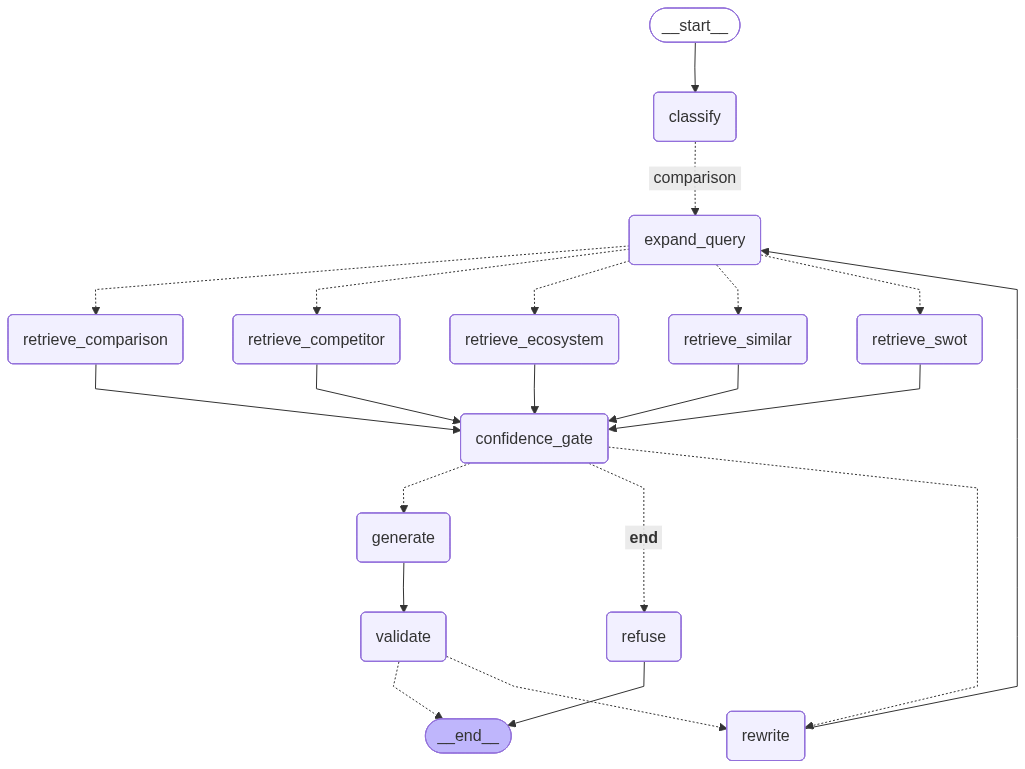

In [5]:
# ── 2b. Render as PNG in the notebook ───────────────────────────────────
from IPython.display import Image, display

png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

## 3. Basic Testing — Invoke the Graph

Run a few sample queries through the full pipeline and inspect results.

In [6]:
# ── Test 1: Similar-company query ───────────────────────────────────────
result = graph.invoke({"user_query": "Find startups similar to Stripe in fintech"})

print(f"Analysis type : {result.get('analysis_type')}")
print(f"Confidence    : {result.get('confidence')}")
print(f"Best score    : {result.get('best_score', 0):.4f}")
print(f"Sources       : {len(result.get('source_docs', []))} docs")
print("─" * 60)
print(result.get("answer", "<no answer>"))

Analysis type : similar
Confidence    : high
Best score    : 3.1247
Sources       : 5 docs
────────────────────────────────────────────────────────────
To find similar startups to Stripe in fintech, I'll look for companies that provide payment processing, infrastructure, or related financial services. Based on the provided data, here are the similar startups:

1. **Dapi** (US, 2019) — Similar to Stripe, Dapi provides a financial technology infrastructure with a universal real-time banking API that enables bank payments, aiming to disintermediate the processing industry.
2. **hyperWALLET Systems** (CAN, 2000) — Like Stripe, hyperWALLET delivers secure, global-grade payment technologies, including online and mobile payments, international payments, and card products, to organizations accessing the global financial network.
3. **Proper** (US, 2021) — Similar to Stripe, Proper provides software and APIs to help fintechs manage their payments data across providers, connecting banks, APIs pr

In [7]:
# ── Test 2: SWOT query ──────────────────────────────────────────────────
result2 = graph.invoke({"user_query": "SWOT analysis of Airbnb"})

print(f"Analysis type : {result2.get('analysis_type')}")
print(f"Confidence    : {result2.get('confidence')}")
print(f"Best score    : {result2.get('best_score', 0):.4f}")
print(f"Sources       : {len(result2.get('source_docs', []))} docs")
print("─" * 60)
print(result2.get("answer", "<no answer>"))

Analysis type : swot
Confidence    : none
Best score    : -3.3743
Sources       : 5 docs
────────────────────────────────────────────────────────────
🚫 **I don't have enough information to answer this reliably.**

The retrieved context doesn't appear relevant to your query. This can happen when:
- The topic is outside the startup database's coverage
- The query is too vague or ambiguous
- No matching startups exist in our 134K dataset

*Try rephrasing your query or broadening your search terms.*


In [8]:
# ── Test 3: Edge case — nonsensical query (should trigger low/no confidence) ──
result3 = graph.invoke({"user_query": "xyzzy plugh nothing here 12345"})

print(f"Analysis type : {result3.get('analysis_type')}")
print(f"Confidence    : {result3.get('confidence')}")
print(f"Best score    : {result3.get('best_score', 0):.4f}")
print("─" * 60)
print(result3.get("answer", "<no answer>")[:300])

Analysis type : similar
Confidence    : none
Best score    : -9.8948
────────────────────────────────────────────────────────────
🚫 **I don't have enough information to answer this reliably.**

The retrieved context doesn't appear relevant to your query. This can happen when:
- The topic is outside the startup database's coverage
- The query is too vague or ambiguous
- No matching startups exist in our 134K dataset

*Try rephr


In [9]:
# ── Test 4: Competitor query ────────────────────────────────────────────
result4 = graph.invoke({"user_query": "Who are the main competitors of Notion?"})

print(f"Analysis type : {result4.get('analysis_type')}")
print(f"Confidence    : {result4.get('confidence')}")
print(f"Best score    : {result4.get('best_score', 0):.4f}")
print(f"Sources       : {len(result4.get('source_docs', []))} docs")
print("─" * 60)
print(result4.get("answer", "<no answer>"))

Analysis type : competitor
Confidence    : high
Best score    : 1.6709
Sources       : 5 docs
────────────────────────────────────────────────────────────
## Direct Competitors
Based on the provided startup data, the direct competitors of Notion (although Notion is not explicitly mentioned, we can infer based on the industry and tags) are:
- Taskade: Offers real-time organization, collaboration, and note-taking features.
- WorkFlowy: Provides a powerful interface for hierarchical lists, which can be used for note-taking and organization.
- Samepage: Offers a collaborative platform with note-taking, task management, and real-time collaboration features.

## Indirect Competitors
Indirect competitors in adjacent markets or with different approaches are:
- Comindwork: Focuses on project management and knowledge worker collaboration, offering a broader set of tools.
- BlitzIQ: Targets B2B sales teams with a note-taking workspace, which is a more specific use case.

## Key Differentiators
- 